# 位置情報は緯度経度で距離感を加味したいな！
# validationデータの切り方も重要か？

★実行環境の選択

In [41]:
# VSCodeの場合
edi_flg = 1
# Googlre Colabの場合
# edi_flg = 0

In [42]:
if edi_flg == 0:
  # GoogleColabにGitHubリポジトリをクローンする用
  %cd /content/My_Python_project

  from google.colab import auth
  auth.authenticate_user()
  !git clone https://github.com/keiseki-eng/My_Python_project
  !git pull origin main



In [43]:
# import sys
# !{sys.executable} -m pip install ipykernel

In [44]:
import os
import sys
import yaml
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import japanize_matplotlib

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, KFold

# srcディレクトリをPythonの検索パスに追加
sys.path.append("/home/keiseki/JR_train_snow/30.src")

# validation.pyからsplit_timeを読み込み
from utils.validation import split_time

In [45]:
if edi_flg == 0:
  from google.colab import drive
  drive.mount('/content/drive')

In [46]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=pd.errors.PerformanceWarning
)

## 01.config読み込み

In [47]:
# VSCode用
if edi_flg==1:
  conf_path = os.path.join( '../00.config/config.yaml')
  path_set = os.path.join('../00.config/path.yaml')
  with open(conf_path, 'r') as f:
    config = yaml.safe_load(f)
  with open(path_set, 'r') as f:
    path_config = yaml.safe_load(f)

# GoogleColab用
elif edi_flg==0:
  conf_path = "My_Python_project/config/config.yaml"
  path_set = "My_Python_project/config/path.yaml"
  with open(conf_path, "r") as f:
    config = yaml.safe_load(f)
  with open(path_set, "r") as f:
    path_config = yaml.safe_load(f)

In [48]:
# 定義した特徴量リストを読み込み
feature_list = config['FEATURE']['FEATURE_LIST']
# カテゴリカルカラムのリストを定義
categorical_cols = config['FEATURE']['CATEGORICAL_COLS']

# 気象データ分
locations = config["WEATHER_FEATURE"]["locations"]
variables = config["WEATHER_FEATURE"]["variables"]
hours = config["WEATHER_FEATURE"]["hours"]
w_categories = config["WEATHER_CATEGORY"]["WEATHER_CATEGORY_LIST"]

# 気象データの特徴量リストを作成
weather_feature_cols = [
    f"{location}_{variable}_{hour}"
    for location in locations
    for variable in variables
    for hour in hours
]
weather_categorical_cols = [
    f"{location}_{w_category}_{hour}"
    for location in locations
    for w_category in w_categories
    for hour in hours
]

# 積雪計データ分
snow_locations = config["SNOW_FEATURE"]["locations"]
snow_variables = config["SNOW_FEATURE"]["variables"]
snow_statistics = config["SNOW_FEATURE"]["statistics"]
snow_time_zones = config["SNOW_FEATURE"]["time_zones"]
snow_categories = config["SNOW_CATEGORY"]["SNOW_CATEGORY_LIST"]

# 積雪計データの特徴量リストを作成
snow_feature_cols = [
    f"{location}_{variable}_{statistic}_{time_zone}"
    for location in snow_locations
    for variable in snow_variables
    for statistic in snow_statistics
    for time_zone in snow_time_zones
]
snow_categorical_cols = [
    f"{location}_{snow_category}_{time_zone}"
    for location in snow_locations
    for snow_category in snow_categories
    for time_zone in snow_time_zones
]

# 通常の特徴量リストに気象データ分を追加
feature_list += weather_feature_cols
categorical_cols += weather_categorical_cols
# 通常の特徴量リストに積雪計データ分を追加
feature_list += snow_feature_cols
categorical_cols += snow_categorical_cols

In [49]:
# 学習データ、テストデータの読み込み
train_data_path = path_config['INTERIUM_PATH']['train_data']
test_data_path = path_config['INTERIUM_PATH']['test_data']

df_train = pd.read_pickle(train_data_path)
df_test = pd.read_pickle(test_data_path)

## addr1+2に対し、ターゲットエンコーディングを実装

In [50]:
# df_train, addr1_2_global_mean = target_encode_oof(
#     df_train,
#     col="addr1+2",
#     target="money_room",
#     n_splits=5,
#     smoothing=20
# )


## interaction特徴量を追加

## 05.train/valid 分割　＆　target加工

In [51]:
# feature_listに存在しないカラムがあれば、NaNで追加
fix_list = feature_list + ["年月日", "合計"]
df_train = df_train.reindex(columns=fix_list)
# 時系列分析のため、train_test_splitではなくsplit_timeを使用
# X_train, X_valid, y_train, y_valid, = split_time(df_train, split_col="年月日", target_col="合計", split_date="2016-11-01")
# ランダム分割の場合
X_train, X_valid, y_train, y_valid, = train_test_split(df_train, df_train["合計"], test_size=0.2, random_state=42)


In [52]:
print("train:")
print(X_train["年月日"].min(), "～", X_train["年月日"].max())

print("valid:")
print(X_valid["年月日"].min(), "～", X_valid["年月日"].max())

train:
2016-01-19 00:00:00 ～ 2016-12-31 00:00:00
valid:
2016-01-19 00:00:00 ～ 2016-12-31 00:00:00


## 07.モデル学習

In [53]:
def wmae_eval(preds, train_data):
    y_true = train_data.get_label()

    # コンペ指定の重み
    weights = np.abs(y_true) * 1e4 + 1

    wmae = np.sum(weights * np.abs(y_true - preds)) / np.sum(weights)

    return "WMAE", wmae, False

In [54]:
# 学習データの前処理:特徴量リストに限定
X_train = X_train[feature_list].copy()
X_valid = X_valid[feature_list].copy()
    
# ：object型の列をcategoryへ
cat_cols = [c for c in categorical_cols if c in X_train.columns]
# 明示的にobject型の全列もcategoryに変換（未指定のカテゴリ列がある場合に備えて）
obj_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

for df in [X_train, X_valid, df_test]:
    cols = sorted(set(cat_cols + obj_cols).intersection(df.columns))
    if cols:
        df[cols] = df[cols].astype("category")

/tmp/ipykernel_5512/4221972066.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


In [55]:
for col in [c for c in X_train.columns if "日照時間" in c]:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    X_valid[col] = pd.to_numeric(X_valid[col], errors="coerce")


In [ ]:
# LightGBM のパラメータ設定
params = config['MODEL_PARAMS']

# LightGBM のデータセットを作成
lgb_train = lgb.Dataset(
    X_train,
    y_train,
    categorical_feature=categorical_cols
)


lgb_test = lgb.Dataset(
    X_valid,
    y_valid,
    reference=lgb_train,
    categorical_feature=categorical_cols
)


# モデルの学習
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_test],
    feval=wmae_eval,
    callbacks=[
        lgb.early_stopping(100)
    ]
)

Training until validation scores don't improve for 100 rounds


## 08.評価

特徴量の重要度


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

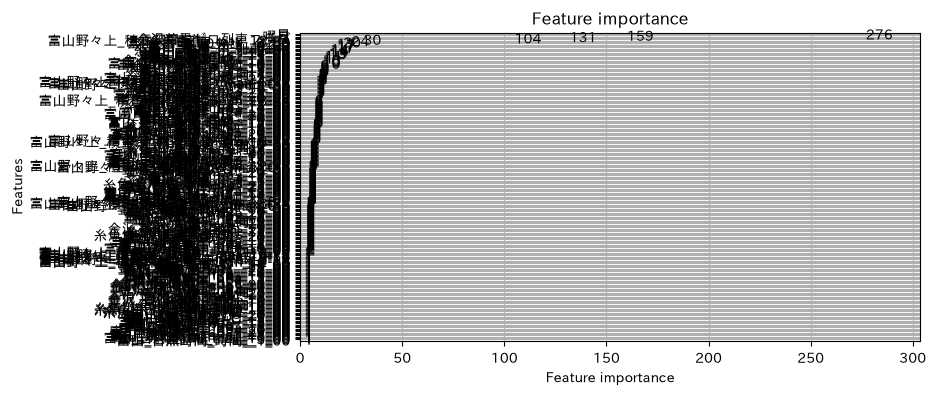

In [ ]:
# 検証データで予測
y_pred = model.predict(X_valid , num_iteration=model.best_iteration)


# 特徴量の重要度
print("特徴量の重要度")
lgb.plot_importance(model, figsize=(8,4))


## 09.可視化（importance SHAP）

In [ ]:

# import lightgbm as lgb
# from sklearn.model_selection import GridSearchCV

# # パラメータの探索範囲を指定
# param_grid = {
#     'num_leaves': [20, 30, 40],
#     'learning_rate': [0.01, 0.1, 0.5],
#     'max_depth': [5, 10]
# }




# # グリッドサーチCV
# gsearch = GridSearchCV(gbm, param_grid, cv=5) #cvは交差検証の回数

# # データを学習
# gsearch.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)])



# # 最適なパラメータとスコアを表示
# print('Best parameters found by grid search are:', gsearch.best_params_)
# print('Best score:', gsearch.best_score_)


In [ ]:
# # パラメータの辞書を結合
# best_params = {**params, **gsearch.best_params_}

# # 最適パラメータでモデルを再学習
# model = lgb.LGBMClassifier(**best_params)
# model.fit(X_train, y_train)

In [ ]:
#SHAP値の取得
explainer = shap.TreeExplainer(model=model)#SHAP値を取得するためのモデル作成
shap_values = explainer.shap_values(X=X_valid)#説明変数それぞれの値のSHAP値を取得する

# print(shap_values)
# print(shap_values.shape)


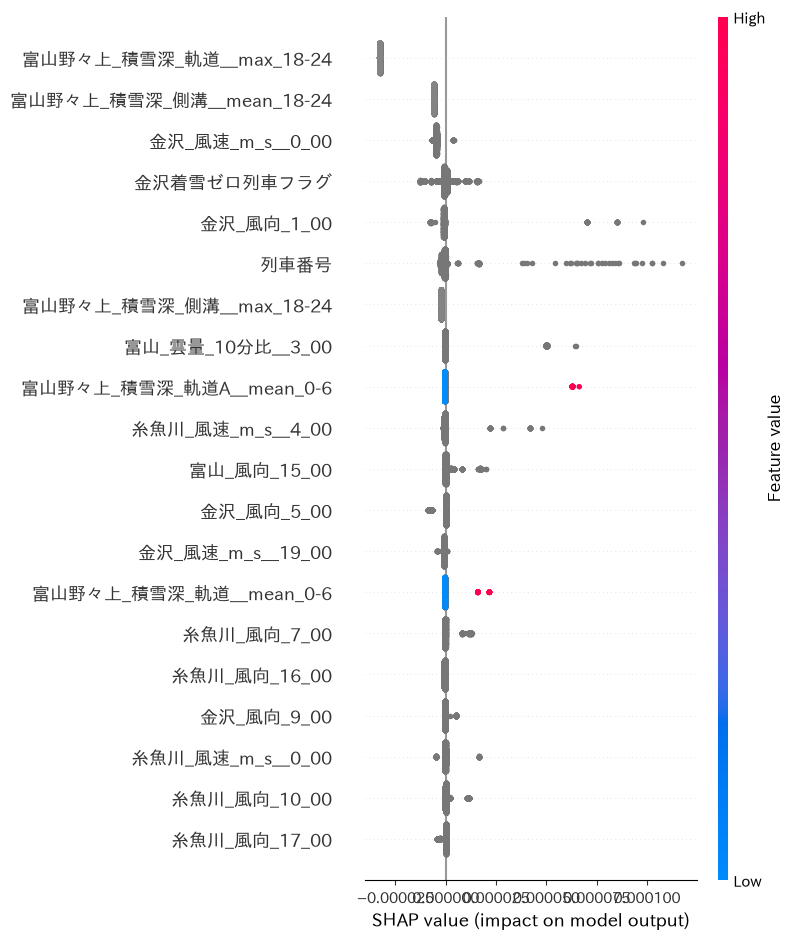

In [ ]:

# 変数別の影響度の可視化
shap.initjs()
# shap.summary_plot(shap_values, X_valid, plot_type="bar", show=False)
shap.summary_plot(shap_values, X_valid, show=False)


# 0番目のデータポイントを再選択
i = 0
single_observation = X_valid.iloc[i:i+1,:]


#print(single_observation)


# Explainerを使って説明を再計算
# single_shap_values = explainer(single_observation)

# waterfallプロットの生成
# shap.waterfall_plot(single_shap_values[0])

## 10.推論、提出

## 提出用データの作成

In [ ]:
# 特徴量の選定
# feature_listに存在しないカラムがあれば、NaNで追加
df_test_p = df_test.reindex(columns=feature_list)

for col in [c for c in X_train.columns if "日照時間" in c]:
    df_test_p[col] = pd.to_numeric(df_test_p[col], errors="coerce")


# 予測
y_pred  = model.predict(df_test_p)
# y_scores_submit = np.clip(y_pred, 6e6, 1e8)

print(y_pred)

[1.05514814e-04 5.90734199e-06 5.70643805e-06 ... 1.14642830e-05
 1.14642830e-05 1.14642830e-05]


In [ ]:

#提出用csvの作成
df_scores_submit = pd.DataFrame(y_pred)

# df_submit = pd.concat([df_test["id"], df_scores_submit], axis=1)
# df_scores_submit.index = df_scores_submit.index + 1
df_scores_submit.to_csv("submit.csv", index=True, header=False)




## 誤差要因分析

<Axes: ylabel='Frequency'>

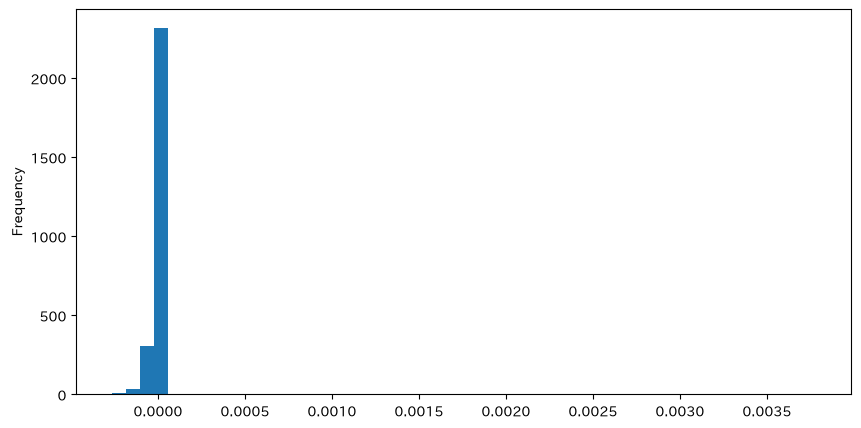

In [ ]:
import numpy as np
import pandas as pd

# Validデータを予測
y_pred = model.predict(X_valid)

# 誤差分析用DataFrame
error_df = X_valid.copy()

error_df["実測値"] = y_valid.values
error_df["予測値"] = y_pred

# 符号付き誤差
# プラス：実測 > 予測 → 過小予測
# マイナス：実測 < 予測 → 過大予測
error_df["誤差"] = error_df["実測値"] - error_df["予測値"]

# 絶対誤差
error_df["絶対誤差"] = np.abs(error_df["誤差"])

# コンテスト評価と同じ重み
error_df["重み"] = np.abs(error_df["実測値"]) * 1e4 + 1

# WMAE用の加重絶対誤差
error_df["加重絶対誤差"] = (
    error_df["重み"] * error_df["絶対誤差"]
)

print(f"Valid件数: {len(error_df):,}")
print(f"Valid MAE : {error_df['絶対誤差'].mean():.6f}")
print(
    f"Valid WMAE: "
    f"{error_df['加重絶対誤差'].sum() / error_df['重み'].sum():.9f}"
)

print(
    error_df[
        ["実測値", "予測値", "誤差", "絶対誤差"]
    ]
    .describe()
)
# 誤差が大きい順に確認
error_df.sort_values(
    "絶対誤差",
    ascending=False
)[
    ["実測値", "予測値", "誤差", "絶対誤差"]
].head(20)

In [ ]:
error_df["実測値_bin"] = pd.cut(
    error_df["実測値"],
    bins=[-np.inf, 0, 0.01, 0.03, 0.05, 0.1, 0.2, np.inf]
)

summary = error_df.groupby(
    "実測値_bin",
    observed=True
).agg(
    件数=("実測値", "size"),
    平均実測=("実測値", "mean"),
    平均予測=("予測値", "mean"),
    MAE=("絶対誤差", "mean"),
    WMAE=("加重絶対誤差", "sum")
)

summary["WMAE"] = (
    summary["WMAE"]
    / error_df.groupby("実測値_bin", observed=True)["重み"].sum()
)

print(summary)

In [ ]:
train_summary = error_df.groupby("列車番号").agg(
    件数=("実測値", "size"),
    平均実測=("実測値", "mean"),
    平均予測=("予測値", "mean"),
    MAE=("絶対誤差", "mean"),
    加重誤差=("加重絶対誤差", "sum"),
    重み=("重み", "sum")
)

train_summary["WMAE"] = (
    train_summary["加重誤差"]
    / train_summary["重み"]
)

print(
    train_summary
    .sort_values("WMAE", ascending=False)
    .head(30)
)

In [ ]:
station_summary = error_df.groupby("駅名").agg(
    件数=("実測値", "size"),
    平均実測=("実測値", "mean"),
    平均予測=("予測値", "mean"),
    MAE=("絶対誤差", "mean"),
    加重誤差=("加重絶対誤差", "sum"),
    重み=("重み", "sum")
)

station_summary["WMAE"] = (
    station_summary["加重誤差"]
    / station_summary["重み"]
)

print(
    station_summary.sort_values(
        "WMAE",
        ascending=False
    )
)

In [ ]:
error_df.sort_values(
    "絶対誤差",
    ascending=False
).head(30)